In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
filepath = "Mutualfund.csv"
df= pd.read_csv(filepath)
raw_df= df.copy()

In [88]:
df.columns=(
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)
text_columns = [
    "scheme_name", "fund_manager", "amc_name",
    "category", "sub_category"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [89]:
missingvalues = pd.DataFrame({
    "missingcount": df.isnull().sum(),
    "missingpercentage": df.isnull().mean()
})
print(missingvalues[missingvalues["missingcount"]>0])

             missingcount  missingpercentage
returns_3yr            21           0.025799
returns_5yr           167           0.205160


In [90]:
riskcolumns=["sortino","alpha","sd", "beta", "sharpe"]
for col in riskcolumns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .replace(["-", "na", "n/a", "nan", ""], np.nan)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")
    print(df[riskcolumns].isnull().sum())

sortino    23
alpha       0
sd          0
beta        0
sharpe      0
dtype: int64
sortino    23
alpha      42
sd          0
beta        0
sharpe      0
dtype: int64
sortino    23
alpha      42
sd         24
beta        0
sharpe      0
dtype: int64
sortino    23
alpha      42
sd         24
beta       42
sharpe      0
dtype: int64
sortino    23
alpha      42
sd         24
beta       42
sharpe     23
dtype: int64


In [91]:
numeric_columns = [
    "min_sip", "min_lumpsum", "expense_ratio",
    "fund_size_cr", "fund_age_yr", "risk_level",
    "rating", "returns_1yr", "returns_3yr", "returns_5yr"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [92]:
duplicate_schemes = df[df.duplicated(subset="scheme_name", keep=False)]
duplicate_schemes = duplicate_schemes.sort_values("scheme_name")

print(duplicate_schemes[
    ["scheme_name", "amc_name", "category",
     "sub_category", "returns_3yr", "expense_ratio"]
])

                           scheme_name                      amc_name  \
75        AXIS Retirement Savings Fund              Axis Mutual Fund   
76        AXIS Retirement Savings Fund              Axis Mutual Fund   
77        AXIS Retirement Savings Fund              Axis Mutual Fund   
94       Bank of India Midcap Tax Fund     Bank of India Mutual Fund   
95       Bank of India Midcap Tax Fund     Bank of India Mutual Fund   
241                    HDFC Index Fund              HDFC Mutual Fund   
242                    HDFC Index Fund              HDFC Mutual Fund   
253       HDFC Retirement Savings Fund              HDFC Mutual Fund   
254       HDFC Retirement Savings Fund              HDFC Mutual Fund   
252       HDFC Retirement Savings Fund              HDFC Mutual Fund   
267           HSBC Corporate Bond Fund              HSBC Mutual Fund   
268           HSBC Corporate Bond Fund              HSBC Mutual Fund   
339          ICICI Pru Retirement Fund  ICICI Prudential Mutual 

In [93]:
df = df.drop_duplicates()

In [94]:
scoring_df = df.dropna(subset=["returns_3yr"]).copy()

In [95]:
for col in riskcolumns:
    df[col] = df.groupby("category")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [96]:
print(df[numeric_columns + riskcolumns].describe().T)

print(df[df["expense_ratio"] < 0])
print(df[df["fund_size_cr"] <= 0])
print(df[df["fund_age_yr"] <= 0])
print(df[~df["risk_level"].between(1, 6)])
print(df[~df["rating"].between(0, 5)])

               count         mean          std    min       25%        50%  \
min_sip        814.0   528.500000   369.184517   0.00  150.0000   500.0000   
min_lumpsum    814.0  3047.468059  2514.619513   0.00  500.0000  5000.0000   
expense_ratio  814.0     0.713231     0.482161   0.00    0.3100     0.6150   
fund_size_cr   814.0  3812.854214  7181.479475   2.38  175.2500   940.5000   
fund_age_yr    814.0     8.319410     2.640622   1.00    6.0000    10.0000   
risk_level     814.0     4.400491     1.814741   1.00    3.0000     6.0000   
rating         814.0     2.641278     1.463476   0.00    2.0000     3.0000   
returns_1yr    814.0     3.921376     6.675502 -19.70    1.5000     4.4000   
returns_3yr    793.0    18.525347    12.108476   3.30    6.2000    18.5000   
returns_5yr    647.0     9.490726     3.714015  -4.10    6.7000     8.9000   
sortino        814.0     2.633120     1.379008  -1.77    1.8000     2.8250   
alpha          814.0     2.427138     3.872940 -13.36    0.5100 

In [97]:
clean_df = df.copy()

clean_df.to_csv("cleaned_mutual_funds_data.csv", index=False)
print("Cleaned file created successfully.")
print(clean_df.shape)

Cleaned file created successfully.
(814, 20)


In [98]:
clean_df = df.copy()

print(clean_df.info())
print(clean_df.isnull().sum())
print("Duplicate full rows:", clean_df.duplicated().sum())
print(clean_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    float64
 8   alpha          814 non-null    float64
 9   sd             814 non-null    float64
 10  beta           814 non-null    float64
 11  sharpe         814 non-null    float64
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    float64
 18  returns_3y

In [99]:
clean_df = df.copy()

print(clean_df.info())
print(clean_df.isnull().sum())
print("Duplicate full rows:", clean_df.duplicated().sum())
print(clean_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    float64
 8   alpha          814 non-null    float64
 9   sd             814 non-null    float64
 10  beta           814 non-null    float64
 11  sharpe         814 non-null    float64
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    float64
 18  returns_3y

In [100]:
df = pd.read_csv("cleaned_dataset.csv")

In [101]:
print(df.shape)
print(df.info())
print(df.head())
print(df.describe())

(814, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    float64
 8   alpha          814 non-null    float64
 9   sd             814 non-null    float64
 10  beta           814 non-null    float64
 11  sharpe         814 non-null    float64
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    float64
 18  

In [102]:
# AMC with highest total AUM
amc_aum = df.groupby("amc_name")["fund_size_cr"].sum().sort_values(ascending=False)
print(amc_aum.head(10))

amc_name
ICICI Prudential Mutual Fund         445257.0
HDFC Mutual Fund                     418426.0
SBI Mutual Fund                      397745.0
Kotak Mahindra Mutual Fund           255952.0
Aditya Birla Sun Life Mutual Fund    227218.0
Axis Mutual Fund                     221203.0
Nippon India Mutual Fund             204320.0
UTI Mutual Fund                      153056.0
DSP Mutual Fund                      107188.0
Mirae Asset Mutual Fund              107063.0
Name: fund_size_cr, dtype: float64


In [103]:
# Category with highest average 3-year return
category_returns = df.groupby("category")["returns_3yr"].mean().sort_values(ascending=False)
print(category_returns)

category
Equity               29.738111
Other                20.792405
Solution Oriented    18.167857
Hybrid               15.272414
Debt                  6.228517
Name: returns_3yr, dtype: float64


In [104]:
# Average expense ratio
print("Average expense ratio:", df["expense_ratio"].mean())

Average expense ratio: 0.7132309582309582


In [105]:
# Fund with highest 3-year return
print(df.loc[df["returns_3yr"].idxmax(), ["scheme_name", "returns_3yr"]])

scheme_name    Quant Small Cap Fund
returns_3yr                    71.4
Name: 608, dtype: object


In [106]:
# Fund with highest 1-year return
print(df.loc[df["returns_1yr"].idxmax(), ["scheme_name", "returns_1yr"]])

scheme_name    Bank of India Credit Risk Fund
returns_1yr                             130.8
Name: 89, dtype: object


In [107]:
# Risk-level distribution
print(df["risk_level"].value_counts().sort_index())

risk_level
1     53
2    127
3    124
4     65
5     27
6    418
Name: count, dtype: int64


AUM by AMC Bar chart

/tmp/ipykernel_3507/2477417608.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_amcs.values, y=top_amcs.index, palette="Blues_r")


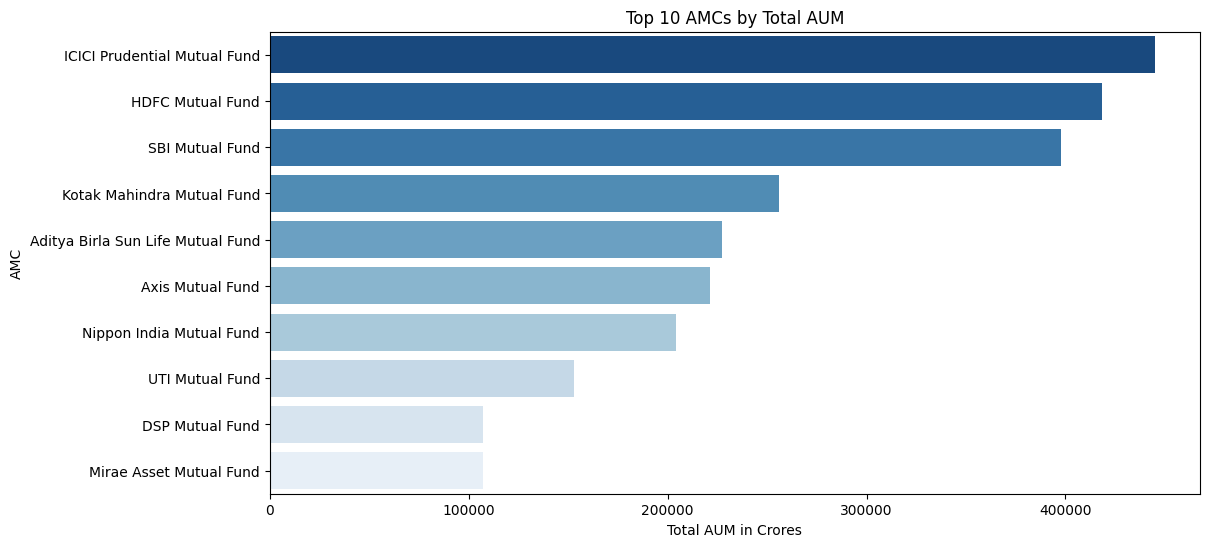

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

top_amcs = amc_aum.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_amcs.values, y=top_amcs.index, palette="Blues_r")
plt.title("Top 10 AMCs by Total AUM")
plt.xlabel("Total AUM in Crores")
plt.ylabel("AMC")
plt.show()

Risk level distribution count plot

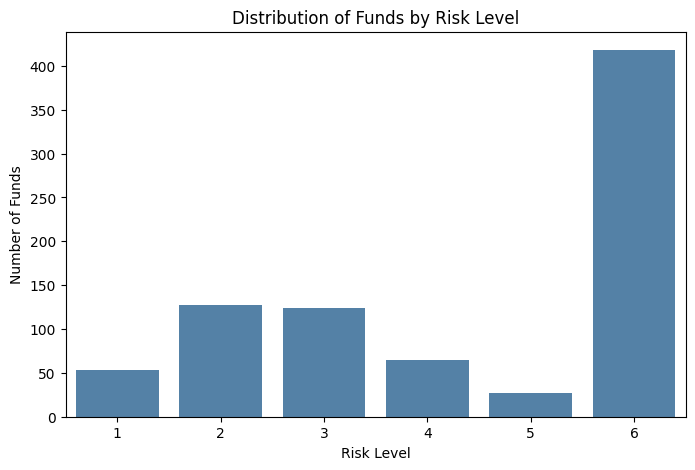

In [109]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="risk_level", color="steelblue")
plt.title("Distribution of Funds by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Funds")
plt.show()

3year returns by category box plot

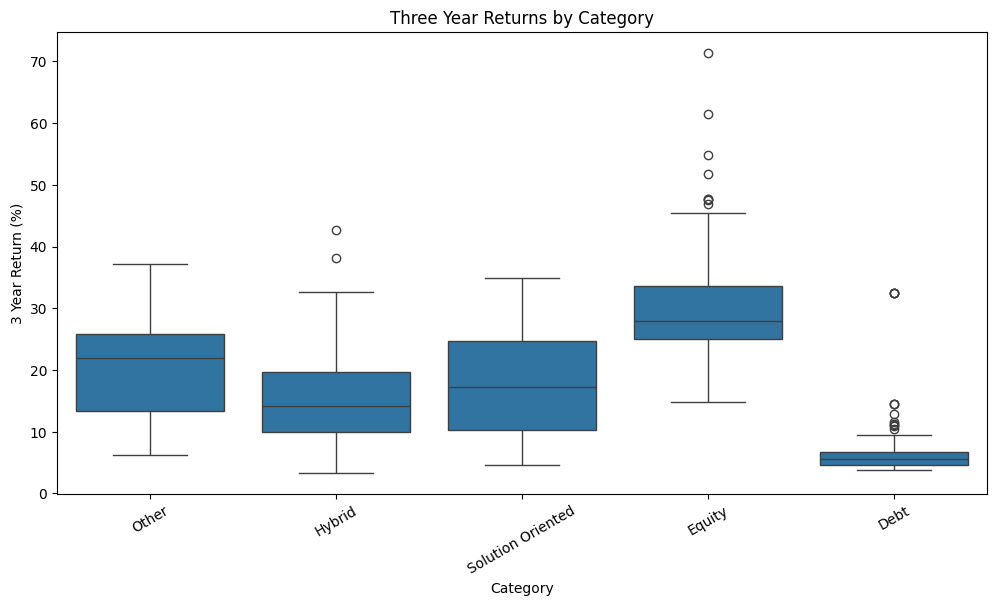

In [110]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="category", y="returns_3yr")
plt.title("Three Year Returns by Category")
plt.xlabel("Category")
plt.ylabel("3 Year Return (%)")
plt.xticks(rotation=30)
plt.show()

Expense ratio distribution - histogram

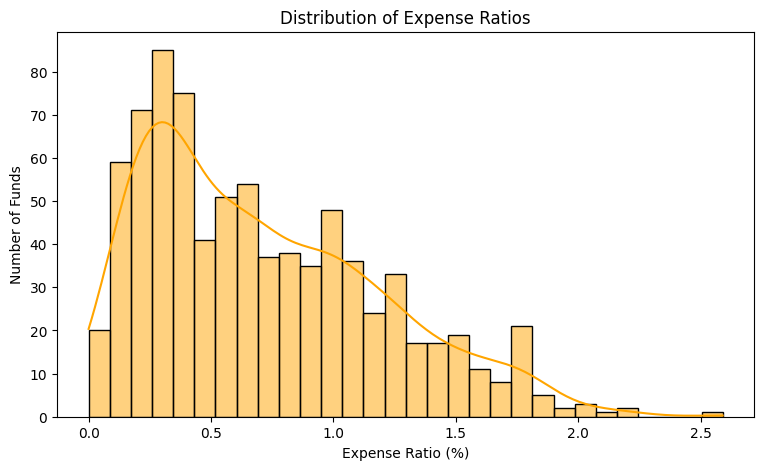

In [111]:
plt.figure(figsize=(9, 5))
sns.histplot(df["expense_ratio"], bins=30, kde=True, color="orange")
plt.title("Distribution of Expense Ratios")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")
plt.show()

Risk versus return

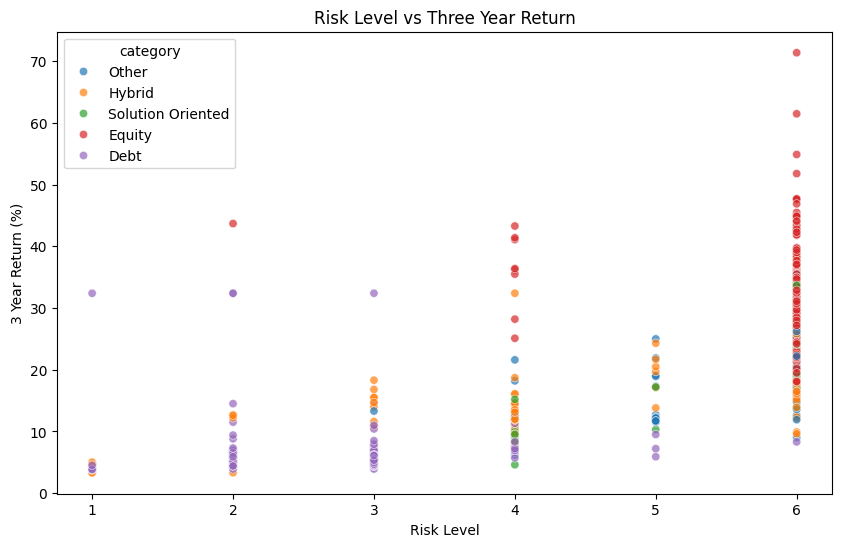

In [112]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="risk_level",
    y="returns_3yr",
    hue="category",
    alpha=0.7
)
plt.title("Risk Level vs Three Year Return")
plt.xlabel("Risk Level")
plt.ylabel("3 Year Return (%)")
plt.show()

Identifying outliers

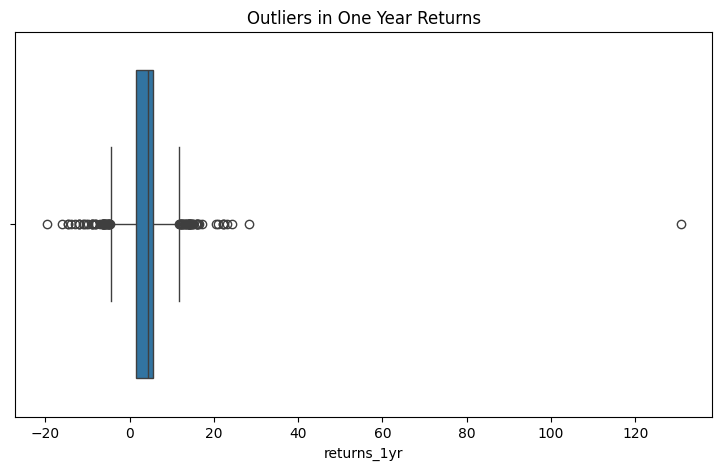

                                          scheme_name  returns_1yr  risk_level
89                     Bank of India Credit Risk Fund        130.8           4
97    Bank of India Short Term Income – Direct Growth         28.3           2
321                     ICICI Pru Infrastructure Fund         24.3           6
451  Kotak Infrastructure & Ecoc. Reform-SP-DirGrowth         23.2           6
88             Bank of India Conservative Hybrid Fund         22.3           3
34   Aditya Birla SL Medium Term Plan – Direct Growth         22.1           4
300          ICICI Pru BHARAT 22 FOF  – Direct Growth         22.1           6
314                               ICICI Pru FMCG Fund         21.1           6
566                   Nippon India Power & Infra Fund         20.4           6
741                               Tata Small Cap Fund         17.1           6


In [113]:
plt.figure(figsize=(9, 5))
sns.boxplot(x=df["returns_1yr"])
plt.title("Outliers in One Year Returns")
plt.show()

print(df.nlargest(10, "returns_1yr")[["scheme_name", "returns_1yr", "risk_level"]])

In [114]:
df.to_csv("mutualfunds_eda.csv",index=False)

CONCLUSION THROUGH MY EDA : Equity funds delivered the highest average 3-year returns, but they are generally associated with higher risk. ICICI Prudential Mutual Fund manages the largest AUM. The dataset is dominated by risk level 6 funds, showing that many available schemes are high risk. Therefore, investors should compare return, risk, and expense ratio together instead of selecting a fund only because it has the highest recent return.

In [115]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [116]:
df = pd.read_csv("mutualfunds_eda.csv")

In [117]:
scoring_df = df.dropna(subset=["returns_3yr"]).copy()
score_columns = ["returns_3yr","expense_ratio","fund_age_yr","returns_1yr"]
scaler = MinMaxScaler()
scoring_df[["returns_3yr_scaled","expense_ratio_scaled","fund_age_scaled","returns_1yr_scaled"]
           ] = scaler.fit_transform(scoring_df[score_columns])
scoring_df["expense_score"] = 1 - scoring_df["expense_ratio_scaled"]

In [118]:
scoring_df.to_csv("mutualfunds_normalized.csv", index=False)

FUND SCORE

In [119]:
scoring_df["fund_score"] = (
    scoring_df["returns_3yr_scaled"] * 0.40 +
    scoring_df["expense_score"] * 0.30 +
    scoring_df["fund_age_scaled"] * 0.20 +
    scoring_df["returns_1yr_scaled"] * 0.10
)
scoring_df["fund_score"] = scoring_df["fund_score"] * 100

In [120]:
scoring_df = scoring_df.sort_values(
    by="fund_score",
    ascending=False
).reset_index(drop=True)
scoring_df["position"] = scoring_df.index + 1

In [121]:
scoring_df["fund_rank"] = np.select(
    [
        scoring_df["fund_score"] >= 70,
        scoring_df["fund_score"] >= 50
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

In [122]:
print(
    scoring_df[
        ["scheme_name", "fund_score", "fund_rank",
         "returns_3yr", "expense_ratio", "risk_level"]
    ].head(30)
)

                                          scheme_name  fund_score fund_rank  \
0                                Quant Small Cap Fund   75.504647         A   
1                           Quant Infrastructure Fund   69.702958         B   
2                       Quant Tax Plan- Direct Growth   66.324824         B   
3                                Quant Flexi Cap Fund   62.371946         B   
4                                   Quant Active Fund   60.694346         B   
5                                  Quant Mid Cap Fund   60.398520         B   
6                              Quant Multi Asset Fund   59.860503         B   
7                PGIM India Midcap Opportunities Fund   59.373587         B   
8                         Nippon India Small Cap Fund   59.196211         B   
9                                Kotak Small Cap Fund   59.055868         B   
10                  ICICI Pru Thematic Advantage Fund   58.876647         B   
11                       Canara Robeco Small Cap Fun

In [123]:
scoring_df.to_csv("ranked_mutualfunds.csv", index=False)

print("Ranked mutual funds file created successfully.")

Ranked mutual funds file created successfully.


In [124]:
top_30 = scoring_df.head(30).copy()
top_30_final = top_30[
    [
        "position",
        "fund_rank",
        "scheme_name",
        "amc_name",
        "category",
        "sub_category",
        "fund_manager",
        "fund_score",
        "returns_1yr",
        "returns_3yr",
        "returns_5yr",
        "expense_ratio",
        "fund_size_cr",
        "fund_age_yr",
        "risk_level",
        "rating"
    ]
]

In [125]:
top_30_final.to_excel(
    "top_30_mutual_funds.xlsx",
    index=False
)

print("Top 30 Excel file created successfully.")

Top 30 Excel file created successfully.


In [126]:
print(top_30_final["category"].value_counts())

category
Equity    23
Other      4
Hybrid     3
Name: count, dtype: int64


In [127]:
print(top_30_final["amc_name"].value_counts())

amc_name
Quant Mutual Fund               8
ICICI Prudential Mutual Fund    5
Kotak Mahindra Mutual Fund      3
Tata Mutual Fund                2
HDFC Mutual Fund                2
Navi Mutual Fund                2
SBI Mutual Fund                 2
PGIM India Mutual Fund          1
Nippon India Mutual Fund        1
HSBC Mutual Fund                1
Canara Robeco Mutual Fund       1
Sundaram Mutual Fund            1
Edelweiss Mutual Fund           1
Name: count, dtype: int64


In [128]:
print(top_30_final["risk_level"].value_counts().sort_index())

risk_level
5     1
6    29
Name: count, dtype: int64


In [129]:
print(top_30_final[
    ["fund_score", "returns_1yr", "returns_3yr",
     "expense_ratio", "fund_age_yr", "risk_level"]
].mean())

fund_score       58.552225
returns_1yr       5.293333
returns_3yr      42.316667
expense_ratio     0.549000
fund_age_yr       9.266667
risk_level        5.966667
dtype: float64


In [130]:
print(top_30_final.iloc[0])

position                              1
fund_rank                             A
scheme_name        Quant Small Cap Fund
amc_name              Quant Mutual Fund
category                         Equity
sub_category     Small Cap Mutual Funds
fund_manager             Sanjeev Sharma
fund_score                    75.504647
returns_1yr                         5.4
returns_3yr                        71.4
returns_5yr                        23.2
expense_ratio                      0.64
fund_size_cr                     3301.0
fund_age_yr                          10
risk_level                            6
rating                                5
Name: 0, dtype: object
